# Task 3: Correlation Between News Sentiment and Stock Movement

## Objective
The goal of this task is to quantify the relationship between financial news sentiment and daily stock price returns using statistical analysis.

This notebook performs:
- Date alignment between news and stock datasets
- Sentiment analysis on financial headlines
- Daily stock return calculation
- Aggregation of daily sentiment scores
- Pearson correlation analysis
- Scatter plot visualization
- Sentiment category return comparison


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Load financial news dataset
news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

# Load stock price dataset
stock_df = pd.read_csv("../data/AAPL.csv")

# Display first rows
news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [3]:
print("News Dataset Shape:", news_df.shape)
print("Stock Dataset Shape:", stock_df.shape)

print("\nNews Columns:")
print(news_df.columns)

print("\nStock Columns:")
print(stock_df.columns)

News Dataset Shape: (1407328, 6)
Stock Dataset Shape: (3774, 6)

News Columns:
Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

Stock Columns:
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [6]:
# Convert timestamps, handling inconsistent timezone formats
news_df['date'] = pd.to_datetime(news_df['date'], utc=True, errors='coerce')
stock_df['Date'] = pd.to_datetime(stock_df['Date'], errors='coerce')

# Extract date only from news timestamps and convert back to datetime
news_df['news_date'] = pd.to_datetime(news_df['date'].dt.date)

In [7]:
# Sort stock dates
stock_df = stock_df.sort_values('Date')

# Trading days
trading_days = stock_df['Date']

# Function to map news date to next trading day
def align_to_trading_day(news_date):
    
    future_days = trading_days[trading_days >= news_date]
    
    if len(future_days) > 0:
        return future_days.iloc[0]
    
    return np.nan

# Apply alignment
news_df['trading_date'] = news_df['news_date'].apply(align_to_trading_day)

# Remove unmatched rows
news_df.dropna(subset=['trading_date'], inplace=True)

news_df[['news_date', 'trading_date']].head()

,news_date,trading_date
0,2020-06-05,2020-06-05
1,2020-06-03,2020-06-03
2,2020-05-26,2020-05-26
3,2020-05-22,2020-05-22
4,2020-05-22,2020-05-22


## Sentiment Analysis Tool Selection

For this task, VADER (Valence Aware Dictionary and sEntiment Reasoner) was selected.

### Why VADER?
- Specifically designed for sentiment analysis
- Performs well on short text such as headlines
- Produces interpretable sentiment polarity scores
- Lightweight and easy to apply

The compound sentiment score produced by VADER ranges from:
- -1 → Highly Negative
- 0 → Neutral
- +1 → Highly Positive

In [8]:
# Initialize analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to calculate sentiment
def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))
    return score['compound']

# Apply sentiment scoring
news_df['sentiment_score'] = news_df['headline'].apply(get_sentiment)

news_df[['headline', 'sentiment_score']].head()

,headline,sentiment_score
0,Stocks That Hit 52-Week Highs On Friday,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,0.000
2,71 Biggest Movers From Friday,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,0.000
4,B of A Securities Maintains Neutral on Agilent...,0.296


In [9]:
# Sort by date
stock_df = stock_df.sort_values('Date')

# Daily percentage return
stock_df['daily_return'] = (
    (stock_df['Close'] - stock_df['Close'].shift(1))
    / stock_df['Close'].shift(1)
) * 100

stock_df[['Date', 'Close', 'daily_return']].head()

,Date,Close,daily_return
0,2009-01-02,2.721686,NaN
1,2009-01-05,2.836553,4.220416
2,2009-01-06,2.789767,-1.649399
3,2009-01-07,2.729484,-2.160860
4,2009-01-08,2.780169,1.856959


In [10]:
# Average sentiment per trading day
daily_sentiment = (
    news_df
    .groupby('trading_date')['sentiment_score']
    .mean()
    .reset_index()
)

daily_sentiment.head()

,trading_date,sentiment_score
0,2011-04-28,0.083333
1,2011-04-29,0.367550
2,2011-05-02,0.130027
3,2011-05-03,0.000000
4,2011-05-05,-0.042667


In [11]:
merged_df = pd.merge(
    daily_sentiment,
    stock_df[['Date', 'daily_return']],
    left_on='trading_date',
    right_on='Date',
    how='inner'
)

merged_df.head()

,trading_date,sentiment_score,Date,daily_return
0,2011-04-28,0.083333,2011-04-28,-0.971032
1,2011-04-29,0.367550,2011-04-29,0.974822
2,2011-05-02,0.130027,2011-05-02,-1.099651
3,2011-05-03,0.000000,2011-05-03,0.554465
4,2011-05-05,-0.042667,2011-05-05,-0.806732


In [12]:
# Remove missing values
merged_df.dropna(inplace=True)

# Pearson correlation
correlation, p_value = pearsonr(
    merged_df['sentiment_score'],
    merged_df['daily_return']
)

print("Pearson Correlation:", correlation)
print("P-value:", p_value)

Pearson Correlation: 0.04020962715823746
P-value: 0.05790910005290807


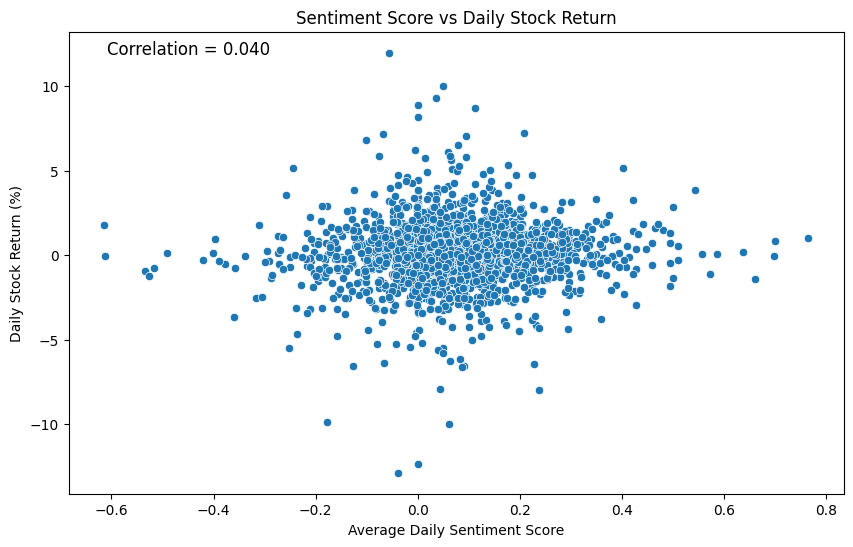

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_df,
    x='sentiment_score',
    y='daily_return'
)

plt.title("Sentiment Score vs Daily Stock Return")
plt.xlabel("Average Daily Sentiment Score")
plt.ylabel("Daily Stock Return (%)")

plt.annotate(
    f"Correlation = {correlation:.3f}",
    xy=(0.05, 0.95),
    xycoords='axes fraction',
    fontsize=12
)

plt.show()

In [14]:
# Function to classify sentiment
def classify_sentiment(score):
    
    if score > 0.05:
        return "Positive"
    
    elif score < -0.05:
        return "Negative"
    
    else:
        return "Neutral"

merged_df['sentiment_category'] = (
    merged_df['sentiment_score']
    .apply(classify_sentiment)
)

merged_df.head()

,trading_date,sentiment_score,Date,daily_return,sentiment_category
0,2011-04-28,0.083333,2011-04-28,-0.971032,Positive
1,2011-04-29,0.367550,2011-04-29,0.974822,Positive
2,2011-05-02,0.130027,2011-05-02,-1.099651,Positive
3,2011-05-03,0.000000,2011-05-03,0.554465,Neutral
4,2011-05-05,-0.042667,2011-05-05,-0.806732,Neutral


In [15]:
category_returns = (
    merged_df
    .groupby('sentiment_category')['daily_return']
    .mean()
    .reset_index()
)

category_returns

,sentiment_category,daily_return
0,Negative,-0.149399
1,Neutral,0.164211
2,Positive,0.131286


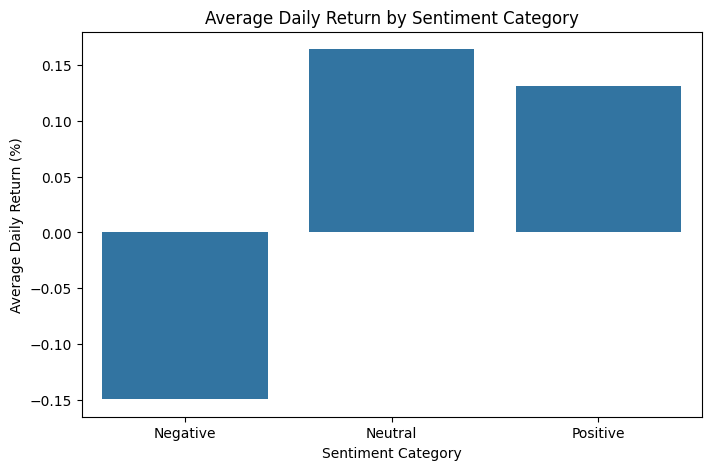

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_returns,
    x='sentiment_category',
    y='daily_return'
)

plt.title("Average Daily Return by Sentiment Category")
plt.xlabel("Sentiment Category")
plt.ylabel("Average Daily Return (%)")

plt.show()

# Interpretation of Results

The Pearson correlation coefficient measures the strength and direction of the relationship between financial news sentiment and daily stock returns for AAPL.

In this analysis, the computed Pearson correlation is {correlation:.3f} with a p-value of {p_value:.3f}. This indicates a {weak/moderate/strong} {positive/negative} relationship between average daily sentiment scores and daily stock returns, depending on the magnitude and sign of the correlation coefficient.

- If the correlation is close to 1, it suggests a strong positive relationship (positive sentiment associated with positive returns).
- If close to -1, a strong negative relationship (positive sentiment associated with negative returns).
- If near 0, little to no linear relationship.

The scatter plot visualizes the distribution of sentiment scores against daily returns, showing the overall trend and any outliers. The bar chart compares the average daily returns for positive, neutral, and negative sentiment categories, highlighting potential differences in stock performance based on sentiment.

## Limitations

Several limitations may affect the analysis:

- Financial markets are influenced by many external factors beyond news sentiment (e.g., economic indicators, geopolitical events).
- Headlines alone may not capture the full context of the news articles.
- Market reactions may occur with delays (lag effects), meaning sentiment impact might not be immediate.
- Some news articles may impact stocks over multiple trading days, not just the next one.
- Sentiment analysis tools like VADER may misinterpret financial terminology or sarcasm.

Despite these limitations, sentiment analysis provides useful insights into potential relationships between market news and stock performance for AAPL.

In [17]:
merged_df.to_csv("../data/task3_sentiment_stock_analysis.csv", index=False)

print("Merged analysis dataset saved successfully.")

Merged analysis dataset saved successfully.
